# Classification and Evaluation in NLP

**Text classification** is a common Natural Language Processing (NLP) task where a model assigns a predefined category or label to a piece of text.

Examples include:
- Spam detection
- Sentiment analysis
- News categorization

In this lab, we will learn how to build and evaluate a text classification model.

## Case Study: Sentiment Analysis

Sentiment analysis, also known as opinion mining, its goal is to understand the information present in the text and categorize it as positive, negative, or neutral.

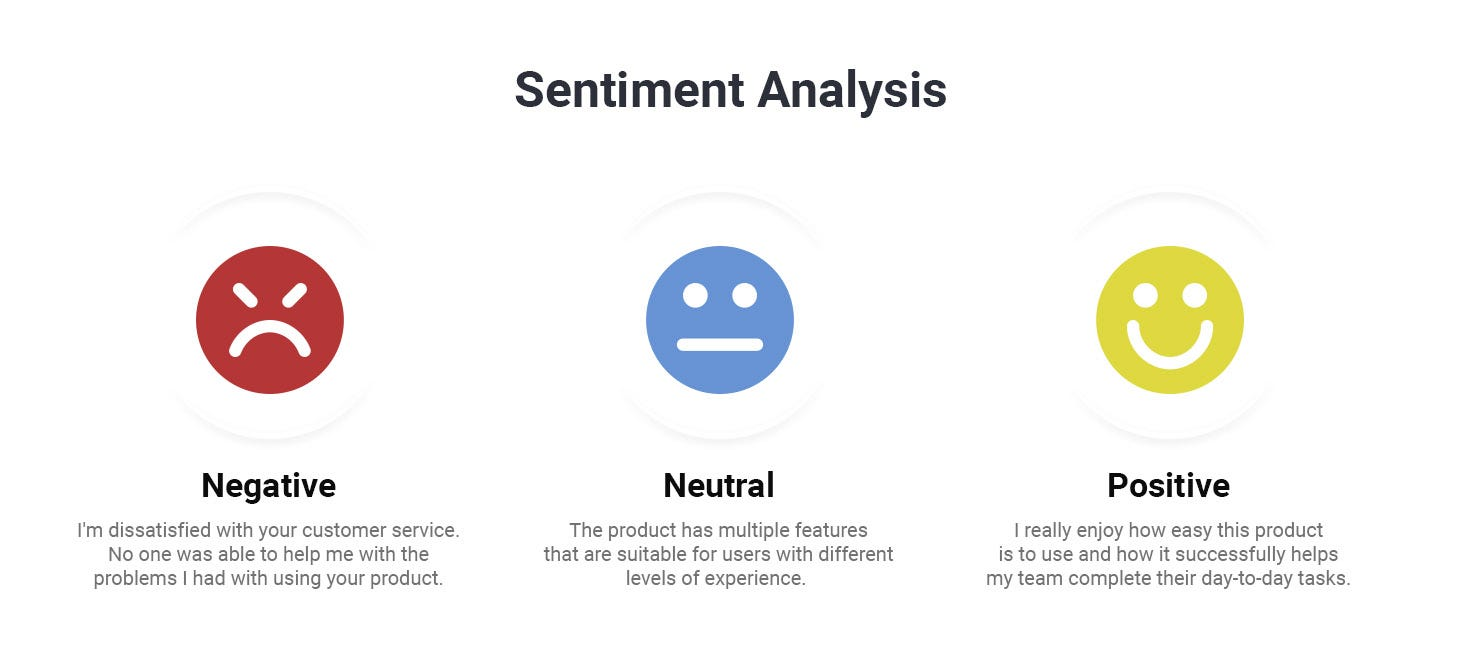

# Disneyland Reviews Dataset
In this lab we'll look into Disneyland Reviews dataset.  
*Link: https://www.kaggle.com/datasets/arushchillar/disneyland-reviews*

The dataset includes 42,000 reviews of 3 Disneyland branches - Paris, California and Hong Kong, posted by visitors on Trip Advisor.

Column Description:

- Review_ID: unique id given to each review
- Rating: ranging from 1 (unsatisfied) to 5 (satisfied)
- Year_Month: when the reviewer visited the theme park
- Reviewer_Location: country of origin of visitor
- Review_Text: comments made by visitor
- Disneyland_Branch: location of Disneyland Park

In [1]:
# Load the dataset
import pandas as pd

data = pd.read_csv('DisneylandReviews.csv', encoding='latin-1')
data

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong
...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris


In [2]:
#Check for missing values
data.isna().sum()

Review_ID            0
Rating               0
Year_Month           0
Reviewer_Location    0
Review_Text          0
Branch               0
dtype: int64

In [3]:
# Drop rows with missing values in the relevant columns
data = data.dropna(subset=['Review_Text', 'Rating'])

In [4]:
# Map star ratings to sentiments
data['Sentiment'] = data['Rating'].apply(lambda rating: 'positive' if rating > 3 else ('negative' if rating < 3 else 'neutral'))
data.head()

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,Sentiment
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,positive
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,positive
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,positive
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,positive
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,positive


In [5]:
# Import necessary libraries
import re
import nltk

def preprocess_text(text):

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenize the text
    words = text.split()

    return ' '.join(words)

# Apply preprocessing to the review text
data['Review_Text'] = data['Review_Text'].apply(preprocess_text)

# Display cleaned reviews
data[['Review_Text', 'Sentiment']].head()

,Review_Text,Sentiment
0,if youve ever been to disneyland anywhere youl...,positive
1,its been a while since d last time we visit hk...,positive
2,thanks god it wasn t too hot or too humid when...,positive
3,hk disneyland is a great compact park unfortun...,positive
4,the location is not in the city took around ho...,positive


In [6]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split the dataset into training and testing sets
train_data, test_data, train_labels, test_labels = train_test_split(data['Review_Text'], data['Sentiment'], test_size=0.2, random_state=42)


# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # You can adjust max_features based on your dataset size - limit vocabulary to the 1000 most informative tokens
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

In [7]:
print(f"train_data size: {train_data.shape}")
print(f"test_data size: {test_data.shape}")

train_data size: (34124,)
test_data size: (8532,)


In [8]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train the Support Vector Machine (SVM) classifier
svm_classifier = SVC(kernel='linear')
svm_classifier.fit(train_vectors, train_labels)

# Predictions on the test set
predictions = svm_classifier.predict(test_vectors)

# Evaluate the model
accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy: {accuracy:.2f}")

# Display classification report
print("Classification Report:")
print(classification_report(test_labels, predictions))


Accuracy: 0.84
Classification Report:
              precision    recall  f1-score   support

    negative       0.64      0.54      0.58       720
     neutral       0.48      0.18      0.26      1035
    positive       0.88      0.98      0.92      6777

    accuracy                           0.84      8532
   macro avg       0.66      0.56      0.59      8532
weighted avg       0.81      0.84      0.81      8532



# Use Case:  Amazon reviews of unlocked phone analysis

The objective of this use case is to conduct sentiment analysis on Amazon reviews of unlocked phones, categorizing reviews into three classes: positive, negative, and neutral. The goal is to gain a comprehensive understanding of customer opinions and sentiments regarding various unlocked phone models.

- Dataset link: https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

Task1: Load the data and do 5 different preprocessing steps on it

Task2: Use a proper train and test split

Task3: Do Feature Extraction Using TF-IDF

Task4: Train a Naive Bayes Classifier

Task5: Evaluate the model on the Test Set

Task6: Print the Confusion Matrix

The dataset contains **413840** reviews from Amazon's unlocked mobile phone category. </br>

**Column Description:**
- **Product Name:** The name of the Product.
- **Brand Name:** Name of the parent company.
- **Price:** Price of the product.
- **Rating:** Rating of the product ranging between 1-5.
- **Reviews:** Description of the user experience.
- **Review Votes:** Number of people voted the review.

### Task 1

In [9]:
# Load the dataset
df = pd.read_csv('Amazon_Unlocked_Mobile.csv', encoding='latin-1')
df

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0
...,...,...,...,...,...,...
413835,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,another great deal great price,0.0
413836,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,3,Ok,0.0
413837,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,Passes every drop test onto porcelain tile!,0.0
413838,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,3,I returned it because it did not meet my needs...,0.0


In [10]:
# Check for missing values
df.isna().sum()

Product Name        0
Brand Name      65171
Price            5933
Rating              0
Reviews            70
Review Votes    12296
dtype: int64

There are some missing values that need to be handled.

In [48]:
# 1. Brand Name: Fill missing values with 'Unknown'
df["Brand Name"] = df["Brand Name"].fillna("Other")

# 2. Price: Fill missing values with the Mean
df["Price"] = df["Price"].fillna(df["Price"].median())

# 3. Reviews: Fill missing reviews with "Not Mentioned"
df["Reviews"] = df["Reviews"].fillna("Not Mentioned")

# 4. Review Votes: Fill missing values with 0, assuming "no votes were recorded"
df["Review Votes"] = df["Review Votes"].fillna(0)

df.isna().sum()

C:\Users\ruqay\AppData\Local\Temp\ipykernel_15744\1258358664.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Brand Name"] = df["Brand Name"].fillna("Other")
C:\Users\ruqay\AppData\Local\Temp\ipykernel_15744\1258358664.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Price"] = df["Price"].fillna(df["Price"].median())
C:\Users\ruqay\AppData\Local\Temp\ipykernel_15744\1258358664.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

Product Name    0
Brand Name      0
Price           0
Rating          0
Reviews         0
Review Votes    0
Sentiment       0
dtype: int64

Now the data is complete without any missing values

In [12]:
# Dataset description
df.describe()

,Price,Rating,Review Votes
count,413840.000000,413840.000000,413840.000000
mean,226.867155,3.819578,1.462454
std,271.042218,1.548216,9.030315
min,1.730000,1.000000,0.000000
25%,79.990000,3.000000,0.000000
50%,149.830000,5.000000,0.000000
75%,269.100000,5.000000,1.000000
max,2598.000000,5.000000,645.000000


In [13]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413840 entries, 0 to 413839
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Product Name  413840 non-null  object 
 1   Brand Name    413840 non-null  object 
 2   Price         413840 non-null  float64
 3   Rating        413840 non-null  int64  
 4   Reviews       413840 non-null  object 
 5   Review Votes  413840 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 18.9+ MB


In [14]:
# Check for duplicated values
print(df.duplicated().sum())

64319


In [15]:
# Remove duplicated values
df = df.drop_duplicates()

# Check the new dataset size
df.shape

(349521, 6)

In [49]:
# Convert reviews to string
df["Reviews"] = df["Reviews"].astype(str)

# Convert text to lowercase
df["Reviews"] = df["Reviews"].str.lower()

# Remove extra whitespace
df["Reviews"] = df["Reviews"].str.replace(r"\s+", " ", regex=True).str.strip()

C:\Users\ruqay\AppData\Local\Temp\ipykernel_15744\3588993032.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Reviews"] = df["Reviews"].astype(str)
C:\Users\ruqay\AppData\Local\Temp\ipykernel_15744\3588993032.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Reviews"] = df["Reviews"].str.lower()
C:\Users\ruqay\AppData\Local\Temp\ipykernel_15744\3588993032.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = v

In [50]:
# Map ratings to sentiments
df['Sentiment'] = df['Rating'].apply(lambda Rating: 'positive' if Rating > 3 else ('negative' if Rating < 3 else 'neutral'))
df.head()

C:\Users\ruqay\AppData\Local\Temp\ipykernel_15744\2619913774.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sentiment'] = df['Rating'].apply(lambda Rating: 'positive' if Rating > 3 else ('negative' if Rating < 3 else 'neutral'))


,Product Name,Brand Name,Price,Rating,Reviews,Review Votes,Sentiment
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,i feel so lucky to have found this used phone ...,1.0,positive
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,nice phone nice up grade from my pantach revue...,0.0,positive
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,very pleased,0.0,positive
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,it works good but it goes slow sometimes but i...,0.0,positive
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,great phone to replace my lost phone the only ...,0.0,positive


In [51]:
# Apply preprocessing to the review text
df['Reviews'] = df['Reviews'].apply(preprocess_text)

# Display cleaned reviews
df[['Reviews', 'Sentiment']].head(10)

C:\Users\ruqay\AppData\Local\Temp\ipykernel_15744\465373562.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Reviews'] = df['Reviews'].apply(preprocess_text)


,Reviews,Sentiment
0,i feel so lucky to have found this used phone ...,positive
1,nice phone nice up grade from my pantach revue...,positive
2,very pleased,positive
3,it works good but it goes slow sometimes but i...,positive
4,great phone to replace my lost phone the only ...,positive
5,i already had a phone with problems i know it ...,negative
6,the charging port was loose i got that soldere...,negative
7,phone looks good but wouldnt stay charged had ...,negative
8,i originally was using the samsung s galaxy fo...,positive
9,its battery life is great its very responsive ...,neutral


In [35]:
df['Sentiment'].value_counts()

Sentiment
positive    236920
negative     84917
neutral      27684
Name: count, dtype: int64

### Task 2

In [52]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df['Reviews'], df['Sentiment'], test_size=0.2, random_state=42, stratify=df['Sentiment'])

### Task 3

In [53]:
# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=6000)
X_train_vectors = tfidf_vectorizer.fit_transform(X_train)
X_test_vectors = tfidf_vectorizer.transform(X_test)

In [54]:
print("Shape before TF-IDF")
print(f"train_data size: {X_train.shape}")
print(f"test_data size: {X_test.shape}")
print("==========================")
print("Shape after TF-IDF")
print(f"train_data size: {X_train_vectors.shape}")
print(f"test_data size: {X_test_vectors.shape}")

Shape before TF-IDF
train_data size: (279616,)
test_data size: (69905,)
Shape after TF-IDF
train_data size: (279616, 6000)
test_data size: (69905, 6000)


### Task 4

In [55]:
from sklearn.naive_bayes import MultinomialNB

# Create the Naive Bayes classifier
nb_classifier = MultinomialNB()

# Train the model
nb_classifier.fit(X_train_vectors, y_train)

MultinomialNB()

### Task 5

In [56]:
# Make predictions to evaluate the model
y_pred = nb_classifier.predict(X_test_vectors)

### Task 6

Confusion Matrix:
[[12584    93  4307]
 [ 1768   192  3577]
 [ 1327   185 45872]]


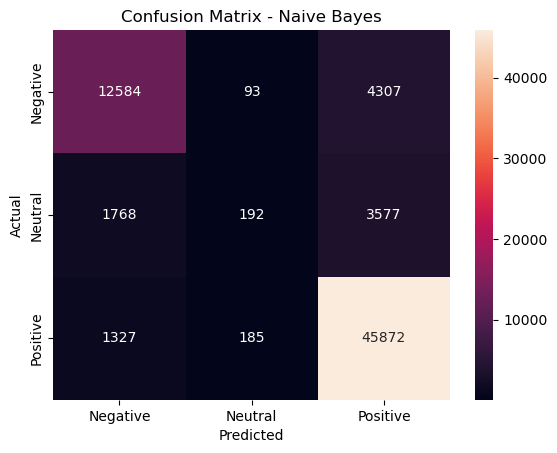

In [57]:
# Confusion matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

In [58]:
# Evaluate the model accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Display classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.84
Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.74      0.77     16984
     neutral       0.41      0.03      0.06      5537
    positive       0.85      0.97      0.91     47384

    accuracy                           0.84     69905
   macro avg       0.69      0.58      0.58     69905
weighted avg       0.81      0.84      0.81     69905



The Naive Bayes model achieved 84% accuracy and a weighted F1-score of 0.81. It performed well in identifying positive and negative reviews, but had difficulty recognizing neutral reviews, because of the class imbaance.